3. Practice with Facebook Prophet

3.1 Installation in Python

In [1]:
from prophet import Prophet

In [2]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

import matplotlib.pyplot as plt
#%config InlineBackend.figure_format = 'retina'

3.2. Dataset

In [3]:
def download_file_from_gdrive(file_url, filename, out_path: Path, overwrite=False):
    """
    Downloads a file from GDrive given an URL
    :param file_url: a string formated as https://drive.google.com/uc?id=<file_id>
    :param: the desired file name
    :param: the desired folder where the file will be downloaded to
    :param overwrite: whether to overwrite the file if it already exists
    """
    file_exists = (out_path / filename).exists()

    if (file_exists and overwrite) or (not file_exists):
        os.system(f'gdown {file_url} -O {out_path}/{filename}')

In [4]:
FILE_URL = "https://drive.google.com/uc?id=1et3FfGQzm_lw0AWtZ0125TKKbD6dTwdi"
FILE_NAME = "medium_posts.csv"
DATA_PATH = Path("../data/large_files")  # not ../../../data/large_files

download_file_from_gdrive(file_url=FILE_URL, filename=FILE_NAME, out_path=DATA_PATH)

df = pd.read_csv(DATA_PATH / FILE_NAME, sep="\t")

In [5]:
df = df[["published", "url"]].dropna().drop_duplicates()

In [6]:
df["published"] = pd.to_datetime(df["published"])

In [7]:
df.sort_values(by=["published"]).head(n=2)

,published,url
50931,1970-01-01 00:00:00.001000+00:00,https://medium.com/iiot
40243,1970-01-01 00:00:00.001000+00:00,https://medium.com/@ikaella/melon-rebranding-b...


In [8]:
df = df[
    (df["published"] > "2012-08-15") & (df["published"] < "2017-06-26")
].sort_values(by=["published"])
df.head(n=3)

,published,url
24630,2012-08-15 00:25:03.373000+00:00,https://medium.com/launch-day/jean-attempts-to...
24631,2012-08-15 00:25:29.419000+00:00,https://medium.com/launch-day/dan-and-kristin-...
17811,2012-08-15 00:34:59.502000+00:00,https://medium.com/i-m-h-o/the-world-is-social...


In [9]:
df.tail(n=3)

,published,url
62122,2017-06-25 23:36:01.171000+00:00,https://medium.com/push-the-pace/the-official-...
72471,2017-06-25 23:41:48.295000+00:00,https://medium.com/parti-xyz-developers/%EA%B4...
83283,2017-06-25 23:51:43+00:00,http://www.johanr.com/blog/people-support-dreams


In [10]:
aggr_df = df.groupby("published")[["url"]].count()
aggr_df.columns = ["posts"]

In [11]:
aggr_df.head(n=3)

,posts
published,
2012-08-15 00:25:03.373000+00:00,1
2012-08-15 00:25:29.419000+00:00,1
2012-08-15 00:34:59.502000+00:00,1


In [12]:
daily_df = aggr_df.resample("D").apply(sum)
daily_df.head(n=3)

,posts
published,
2012-08-15 00:00:00+00:00,16
2012-08-16 00:00:00+00:00,11
2012-08-17 00:00:00+00:00,4


3.3 Exploratory Visual Analysis

In [13]:
from plotly import graph_objs as go
from plotly.offline import init_notebook_mode, iplot, plot
from IPython.display import display, IFrame

# Initialize plotly
init_notebook_mode(connected=True)

In [14]:
def plotly_df(df, title="", width=800, height=500):
    """Visualize all the dataframe columns as line plots."""
    fig = go.Figure()
    for c in df.columns:
        fig.add_trace(go.Scatter(x=df.index, y=df[c], mode="lines", name=c))
    fig.update_layout(title=title, width=width, height=height)
    fig.show()

In [15]:
plotly_df(daily_df, title="Posts on Medium (daily)")

In [16]:
weekly_df = daily_df.resample("W").apply(sum)

In [17]:
plotly_df(weekly_df, title="Posts on Medium (weekly)")

In [18]:
daily_df = daily_df.loc[daily_df.index >= "2015-01-01"]
daily_df.head(n=3)

,posts
published,
2015-01-01 00:00:00+00:00,8
2015-01-02 00:00:00+00:00,11
2015-01-03 00:00:00+00:00,11


3.4. Making a Forecast

In [19]:
import logging

from prophet import Prophet

logging.getLogger().setLevel(logging.ERROR)

In [20]:
df = daily_df.reset_index()
df.columns = ["ds", "y"]
# converting timezones (issue https://github.com/facebook/prophet/issues/831)
df["ds"] = df["ds"].dt.tz_convert(None)
df.tail(n=3)

,ds,y
904,2017-06-23,421
905,2017-06-24,277
906,2017-06-25,253


In [21]:
prediction_size = 30
train_df = df[:-prediction_size]
train_df.tail(n=3)

,ds,y
874,2017-05-24,375
875,2017-05-25,298
876,2017-05-26,269


In [22]:
m = Prophet()
m.fit(train_df);

18:10:09 - cmdstanpy - INFO - Chain [1] start processing


18:10:09 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
future = m.make_future_dataframe(periods=prediction_size)
future.tail(n=3)

,ds
904,2017-06-23
905,2017-06-24
906,2017-06-25


In [24]:
forecast = m.predict(future)
forecast.tail(n=3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
904,2017-06-23,277.550201,255.653219,304.371974,277.173490,277.959304,2.297022,2.297022,2.297022,3.474376,3.474376,3.474376,-1.177354,-1.177354,-1.177354,0.0,0.0,0.0,279.847223
905,2017-06-24,278.264708,218.476033,268.588374,277.860309,278.702690,-35.011675,-35.011675,-35.011675,-34.024396,-34.024396,-34.024396,-0.987279,-0.987279,-0.987279,0.0,0.0,0.0,243.253033
906,2017-06-25,278.979215,222.681046,272.195293,278.551221,279.442977,-31.378345,-31.378345,-31.378345,-30.580653,-30.580653,-30.580653,-0.797691,-0.797691,-0.797691,0.0,0.0,0.0,247.600870


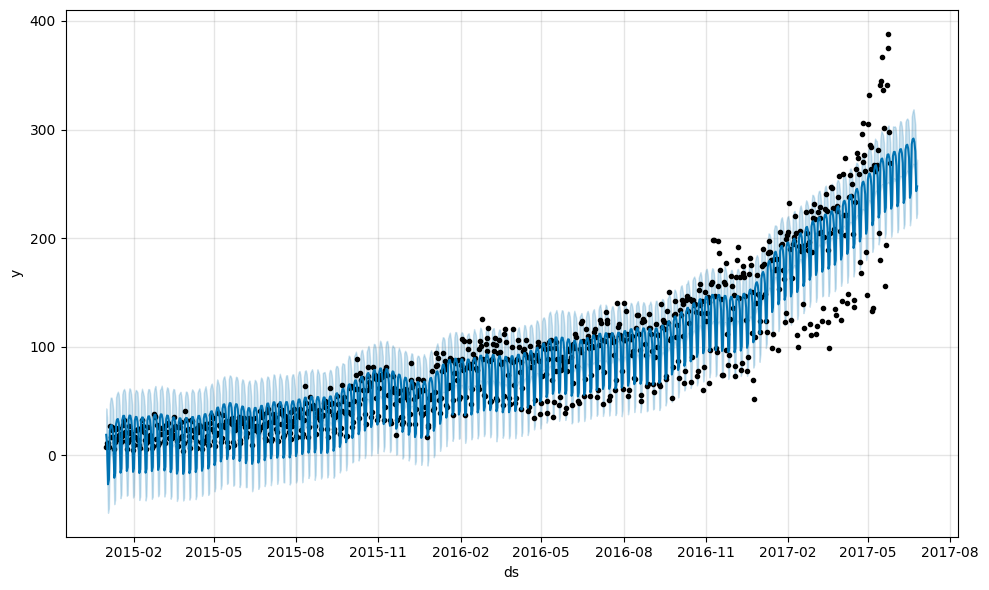

In [25]:
m.plot(forecast);

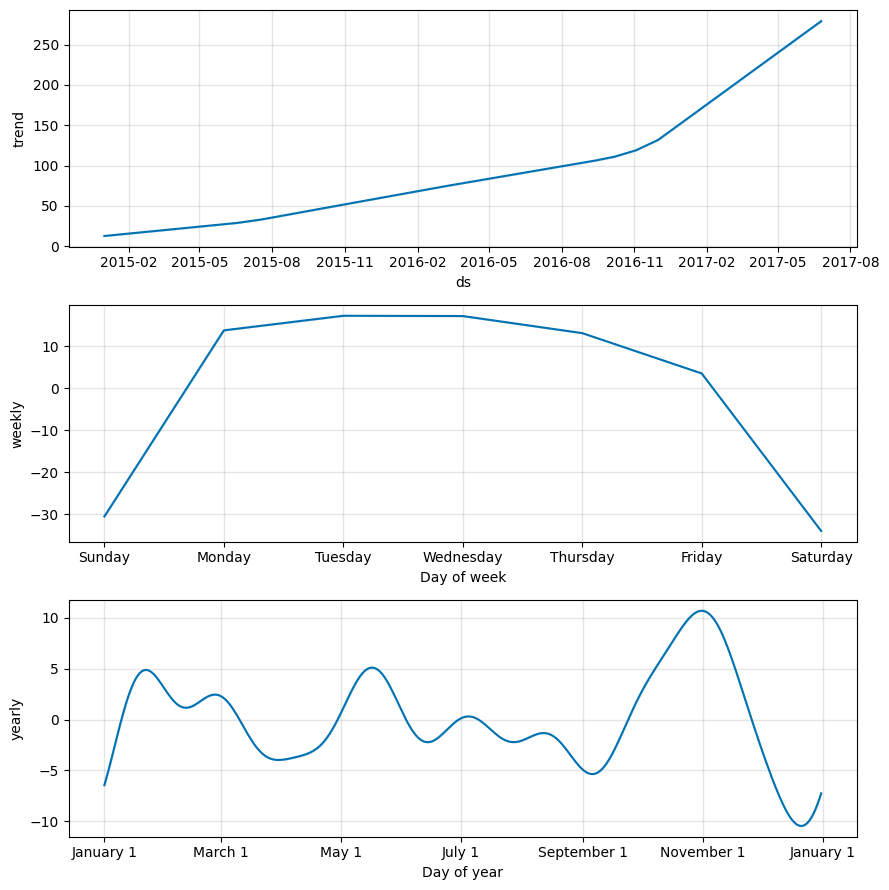

In [26]:
m.plot_components(forecast);

3.5. Forecast Quality Evaluation

In [27]:
print(", ".join(forecast.columns))

ds, trend, yhat_lower, yhat_upper, trend_lower, trend_upper, additive_terms, additive_terms_lower, additive_terms_upper, weekly, weekly_lower, weekly_upper, yearly, yearly_lower, yearly_upper, multiplicative_terms, multiplicative_terms_lower, multiplicative_terms_upper, yhat


In [28]:
def make_comparison_dataframe(historical, forecast):
    """Join the history with the forecast.

       The resulting dataset will contain columns 'yhat', 'yhat_lower', 'yhat_upper' and 'y'.
    """
    return forecast.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]].join(
        historical.set_index("ds")
    )

In [29]:
cmp_df = make_comparison_dataframe(df, forecast)
cmp_df.tail(n=3)

,yhat,yhat_lower,yhat_upper,y
ds,,,,
2017-06-23,279.847223,255.653219,304.371974,421
2017-06-24,243.253033,218.476033,268.588374,277
2017-06-25,247.600870,222.681046,272.195293,253


In [30]:
def calculate_forecast_errors(df, prediction_size):
    """Calculate MAPE and MAE of the forecast.

       Args:
           df: joined dataset with 'y' and 'yhat' columns.
           prediction_size: number of days at the end to predict.
    """

    # Make a copy
    df = df.copy()

    # Now we calculate the values of e_i and p_i according to the formulas given in the article above.
    df["e"] = df["y"] - df["yhat"]
    df["p"] = 100 * df["e"] / df["y"]

    # Recall that we held out the values of the last `prediction_size` days
    # in order to predict them and measure the quality of the model.

    # Now cut out the part of the data which we made our prediction for.
    predicted_part = df[-prediction_size:]

    # Define the function that averages absolute error values over the predicted part.
    error_mean = lambda error_name: np.mean(np.abs(predicted_part[error_name]))

    # Now we can calculate MAPE and MAE and return the resulting dictionary of errors.
    return {"MAPE": error_mean("p"), "MAE": error_mean("e")}

In [31]:
for err_name, err_value in calculate_forecast_errors(cmp_df, prediction_size).items():
    print(err_name, err_value)

MAPE 22.60247233087488
MAE 69.81704699482735


3.6 Visualization

In [32]:
def show_forecast(cmp_df, num_predictions, num_values, title, width=800, height=500):
    """Visualize the forecast."""

    def create_go(name, column, num, **kwargs):
        points = cmp_df.tail(num)
        args = dict(name=name, x=points.index, y=points[column], mode="lines")
        args.update(kwargs)
        return go.Scatter(**args)

    lower_bound = create_go(
        "Lower Bound",
        "yhat_lower",
        num_predictions,
        line=dict(width=0),
        marker=dict(color="gray"),
    )
    upper_bound = create_go(
        "Upper Bound",
        "yhat_upper",
        num_predictions,
        line=dict(width=0),
        marker=dict(color="gray"),
        fillcolor="rgba(68, 68, 68, 0.3)",
        fill="tonexty",
    )
    forecast = create_go(
        "Forecast", "yhat", num_predictions, line=dict(color="rgb(31, 119, 180)")
    )
    actual = create_go("Actual", "y", num_values, marker=dict(color="red"))

    data = [lower_bound, upper_bound, forecast, actual]
    fig = go.Figure(data=data, layout=go.Layout(
        yaxis=dict(title="Posts"), title=title, showlegend=False,
        width=width, height=height,
    ))
    fig.show()

In [33]:
show_forecast(cmp_df, prediction_size, 100, "New posts on Medium")

4. Box-Cox Transformation

In [34]:
def inverse_boxcox(y, lambda_):
    return np.exp(y) if lambda_ == 0 else np.exp(np.log(lambda_ * y + 1) / lambda_)

In [35]:
train_df2 = train_df.copy().set_index("ds")

In [36]:
train_df2["y"], lambda_prophet = stats.boxcox(train_df2["y"])
train_df2.reset_index(inplace=True)

In [37]:
m2 = Prophet()
m2.fit(train_df2)
future2 = m2.make_future_dataframe(periods=prediction_size)
forecast2 = m2.predict(future2)

18:10:12 - cmdstanpy - INFO - Chain [1] start processing
18:10:12 - cmdstanpy - INFO - Chain [1] done processing


In [38]:
for column in ["yhat", "yhat_lower", "yhat_upper"]:
    forecast2[column] = inverse_boxcox(forecast2[column], lambda_prophet)

In [39]:
cmp_df2 = make_comparison_dataframe(df, forecast2)
for err_name, err_value in calculate_forecast_errors(cmp_df2, prediction_size).items():
    print(err_name, err_value)

MAPE 11.675370595197755
MAE 39.437881474072896


In [40]:
show_forecast(cmp_df, prediction_size, 100, "No transformations")
show_forecast(cmp_df2, prediction_size, 100, "Box–Cox transformation")